# Imports

In [67]:
import os
import keras
from PIL import Image
from keras import layers
import matplotlib.pyplot as plt

# Importering av data

In [68]:
if not os.path.exists("data/fashion_mnist_images/train") or not os.path.exists("data/fashion_mnist_images/test"):
    # raderar fel plaserad data eller gammal data
    
    if os.path.exists("data/fashion_mnist_images") and not os.path.exists("data/fashion_mnist_images/train") and not os.path.exists("data/fashion_mnist_images/test"): 
        print("starting to overwrite old data")
        for folder_name in os.listdir("data/fashion_mnist_images"):
            folder_path = os.path.join("data/fashion_mnist_images", folder_name)

            for file_name in os.listdir(folder_path):
                file_path = os.path.join(folder_path ,file_name)
                print(f"is file: {os.path.isfile(file_path)}, {file_path}")
                
                os.remove(file_path)  # Remove the file
                #print(f"removed file {file_path}")
        
        os.rmdir(folder_path)
        print(f"--removed folder {folder_path}")
                
    #  Ladda dataset
        (x_train, y_train),(x_test, y_test) = keras.datasets.fashion_mnist.load_data()

    # Klassnamn (viktigt för mappar)
        class_names = [
            "T-shirt_top", "Trouser", "Pullover", "Dress", "Coat",
            "Sandal", "Shirt", "Sneaker", "Bag", "Ankle_boot"
        ]

        # Root folder
        base_path = "data/fashion_mnist_images"

        # Skapa mappar per klass för tränings data
        if not os.path.exists(f"{base_path}/train"):

            for class_name in class_names:
                os.makedirs(os.path.join(base_path,"train", class_name), exist_ok=True)

            # Spara träningsbilder
            for i, (img, label) in enumerate(zip(x_train, y_train)):

                class_name = class_names[label]
                
                path = os.path.join(base_path,"train", class_name, f"{i}.png")

                image = Image.fromarray(img)  # numpy → bild
                image.save(path)
        else:
             print("Test data already importet")

        if not os.path.exists(f"{base_path}/test"):
            # Skapa mappar per klass på test data

            for class_name in class_names:
                os.makedirs(os.path.join(base_path,"test", class_name), exist_ok=True)

            # Spara testbilder
            for i, (img, label) in enumerate(zip(x_test, y_test)):

                class_name = class_names[label]

                path = os.path.join(base_path,"test", class_name, f"{i}.png")

                image = Image.fromarray(img)  # numpy → bild
                image.save(path)
        else: 
             print("Train data already importet")

        print("Done with importing data")
else:
     print("Data already been imported")

Data already been imported


# Standard model

## Inläsning av data

In [69]:
train_dir = "data/fashion_mnist_images/train"
test_dir = "data/fashion_mnist_images/test"


IMG_SIZE = (28,28)
BATCH_SIZE = 128

train_data = keras.utils.image_dataset_from_directory(
    train_dir,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_data = keras.utils.image_dataset_from_directory(
    test_dir,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
class_names = train_data.class_names
normalization_layer = layers.Rescaling(1./255)

Found 60000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


## Första modelen

In [70]:
model_1 = keras.Sequential([
    layers.Input(shape=(28,28,1)),
    normalization_layer,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(len(class_names), activation='softmax')
])

model_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_1.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Träning

In [71]:
history_1 = model_1.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.8051 - loss: 0.5423 - val_accuracy: 0.8644 - val_loss: 0.3924
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.8725 - loss: 0.3508 - val_accuracy: 0.8767 - val_loss: 0.3376
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.8909 - loss: 0.3020 - val_accuracy: 0.8782 - val_loss: 0.3278
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - accuracy: 0.9011 - loss: 0.2734 - val_accuracy: 0.8964 - val_loss: 0.2861
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - accuracy: 0.9082 - loss: 0.2497 - val_accuracy: 0.8881 - val_loss: 0.3107
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.9145 - loss: 0.2316 - val_accuracy: 0.8978 - val_loss: 0.2811
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - accuracy: 0.9209 - loss: 0.2128 - val_accuracy: 0.9001 - val_loss: 0.2695
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - accuracy: 0.9277 - loss: 0.1972 - 

# Jämförelse Model

## Data föränding

In [72]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2)
])

## Andra model

In [73]:
model_2 = keras.Sequential([
    layers.Input(shape=(28,28,1)),

    data_augmentation,

    normalization_layer,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(len(class_names), activation='softmax')
])

model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_2.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_10 (Sequential)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Träning

In [74]:
history_2 = model_2.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 35s 69ms/step - accuracy: 0.7105 - loss: 0.7822 - val_accuracy: 0.7690 - val_loss: 0.6194
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step - accuracy: 0.7892 - loss: 0.5699 - val_accuracy: 0.7903 - val_loss: 0.5737
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 35s 60ms/step - accuracy: 0.8115 - loss: 0.5058 - val_accuracy: 0.8393 - val_loss: 0.4443
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.8246 - loss: 0.4699 - val_accuracy: 0.8302 - val_loss: 0.4578
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12139s 38ms/step - accuracy: 0.8330 - loss: 0.4456 - val_accuracy: 0.8250 - val_loss: 0.4571
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.8406 - loss: 0.4218 - val_accuracy: 0.8476 - val_loss: 0.4125
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.8499 - loss: 0.4036 - val_accuracy: 0.8102 - val_loss: 0.4785
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.8537 - loss: 0.3899

# Jämförelse

model 1


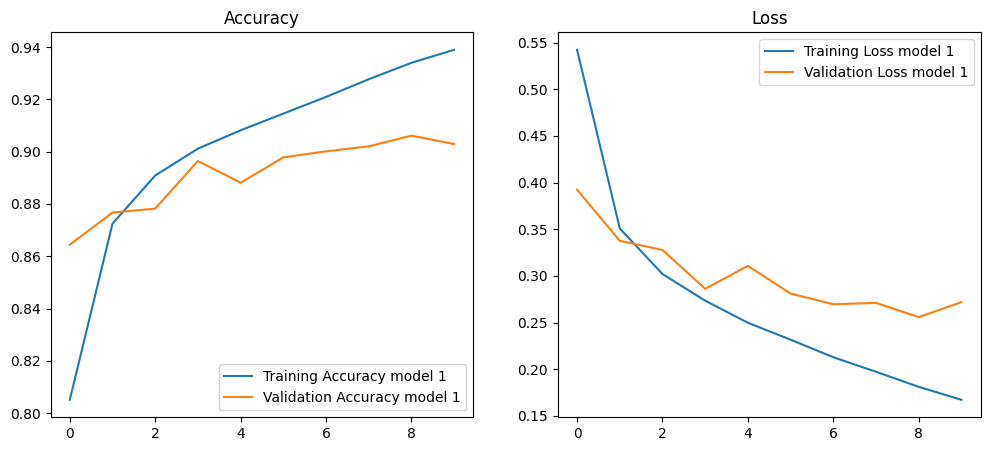

model 2


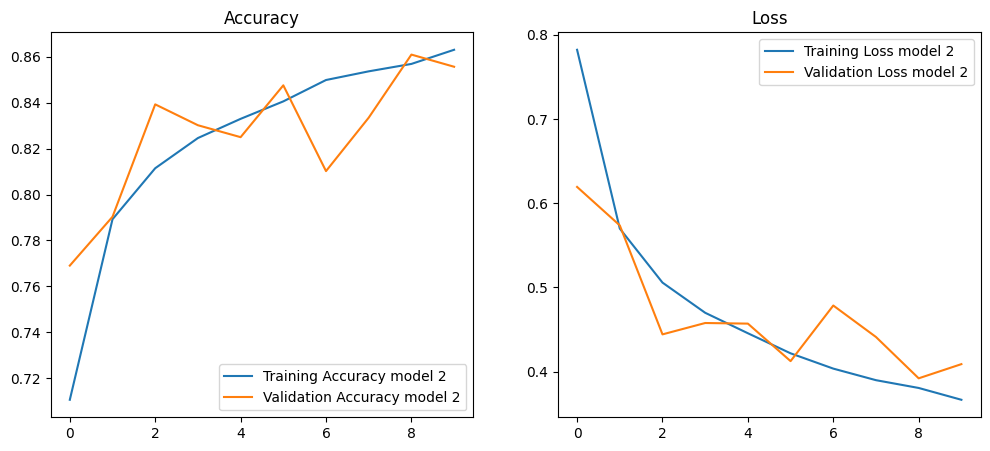

In [76]:

print("model 1")
acc = history_1.history['accuracy']
val_acc = history_1.history['val_accuracy']

loss = history_1.history['loss']
val_loss = history_1.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy model 1')
plt.plot(epochs_range, val_acc, label='Validation Accuracy model 1')
plt.legend(loc='lower right')
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss model 1')
plt.plot(epochs_range, val_loss, label='Validation Loss model 1')
plt.legend(loc='upper right')
plt.title('Loss')

plt.show()

print("model 2")
acc = history_2.history['accuracy']
val_acc = history_2.history['val_accuracy']

loss = history_2.history['loss']
val_loss = history_2.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy model 2')
plt.plot(epochs_range, val_acc, label='Validation Accuracy model 2')
plt.legend(loc='lower right')
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss model 2')
plt.plot(epochs_range, val_loss, label='Validation Loss model 2')
plt.legend(loc='upper right')
plt.title('Loss')

plt.show()